# Teorema de Bayes na prática

**Tema:** Estatística › Estatística Bayesiana

Este notebook constrói o teorema de Bayes **contando pessoas**, antes de
escrever qualquer fórmula. A meta é que, ao fim, a expressão
$P(\theta \mid D) \propto P(D \mid \theta)P(\theta)$ pareça óbvia — e que o
erro da taxa-base fique impossível de cometer.

> **A ideia em uma frase:** a probabilidade de uma hipótese depois de ver os
> dados é a probabilidade que ela tinha antes, reponderada por quão bem ela
> explica o que você viu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(1701)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O teorema, contando pessoas

**Cenário:** uma doença atinge 1 em cada 1.000 pessoas. Existe um exame com
99% de sensibilidade ($P(+ \mid \text{doente})$) e 99% de especificidade
($P(- \mid \text{saudável})$).

Você testou positivo. Qual a chance de estar doente?

Antes de calcular, guarde seu palpite. A maioria das pessoas — incluindo
médicos, em estudos clássicos — responde "99%".

In [2]:
POPULACAO = 1_000_000
PREVALENCIA = 1 / 1000
SENSIBILIDADE = 0.99
ESPECIFICIDADE = 0.99

doentes = POPULACAO * PREVALENCIA
saudaveis = POPULACAO - doentes

verdadeiro_positivo = doentes * SENSIBILIDADE
falso_negativo = doentes * (1 - SENSIBILIDADE)
falso_positivo = saudaveis * (1 - ESPECIFICIDADE)
verdadeiro_negativo = saudaveis * ESPECIFICIDADE

tabela = pd.DataFrame(
    [[verdadeiro_positivo, falso_positivo],
     [falso_negativo, verdadeiro_negativo]],
    index=["exame POSITIVO", "exame NEGATIVO"],
    columns=["doente", "saudável"]).astype(int)
print(tabela.to_string(), "\n")

p_doente_dado_positivo = verdadeiro_positivo / (verdadeiro_positivo + falso_positivo)
print(f"Positivos totais: {int(verdadeiro_positivo + falso_positivo):,}")
print(f"  dos quais realmente doentes: {int(verdadeiro_positivo):,}")
print(f"\nP(doente | positivo) = {p_doente_dado_positivo:.4f}  ->  {p_doente_dado_positivo:.1%}")

                doente  saudável
exame POSITIVO     990      9990
exame NEGATIVO      10    989010 

Positivos totais: 10,980
  dos quais realmente doentes: 990

P(doente | positivo) = 0.0902  ->  9.0%


**9%.** Não 99%.

A razão é puramente aritmética: existem 999.000 pessoas saudáveis, e errar em
1% delas produz **9.990 falsos positivos** — dez vezes mais que os 990
verdadeiros positivos. O exame é excelente; a doença é rara. A raridade vence.

Agora a mesma conta, pela fórmula.

In [3]:
def bayes(priori, verossimilhanca_h, verossimilhanca_nao_h):
    """P(H|D) = P(D|H)P(H) / [P(D|H)P(H) + P(D|~H)P(~H)]"""
    num = verossimilhanca_h * priori
    den = num + verossimilhanca_nao_h * (1 - priori)
    return num / den


print(f"via fórmula: {bayes(PREVALENCIA, SENSIBILIDADE, 1 - ESPECIFICIDADE):.4f}")

via fórmula: 0.0902


## 2. A prevalência é a priori — e ela decide tudo

O mesmo exame, aplicado a populações diferentes, produz conclusões
completamente diferentes. Isso não é falha do exame: é a informação que ele
carrega sendo somada à informação que já existia.

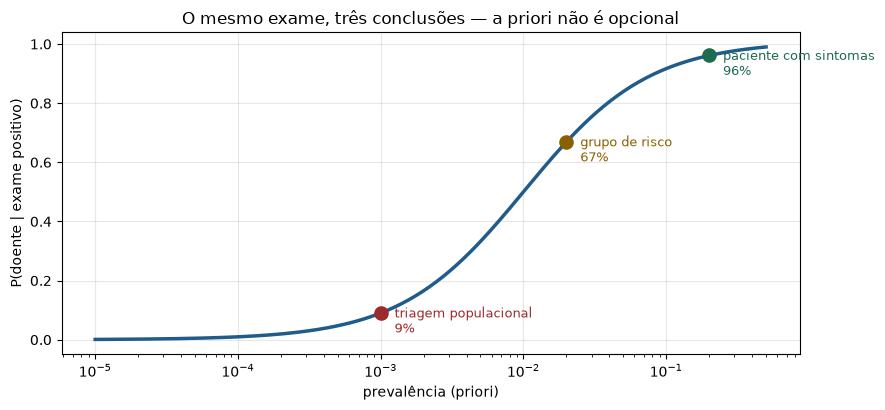

triagem populacional       priori  0.0010  ->  posteriori 0.090
grupo de risco             priori  0.0200  ->  posteriori 0.669
paciente com sintomas      priori  0.2000  ->  posteriori 0.961


In [4]:
prevalencias = np.logspace(-5, -0.3, 200)
posterioris = bayes(prevalencias, SENSIBILIDADE, 1 - ESPECIFICIDADE)

cenarios = {
    "triagem populacional": 1 / 1000,
    "grupo de risco": 1 / 50,
    "paciente com sintomas": 1 / 5,
}

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(prevalencias, posterioris, color=AZUL, lw=2.5)
for (nome, prev), cor in zip(cenarios.items(), [VERMELHO, AMBAR, VERDE]):
    post = bayes(prev, SENSIBILIDADE, 1 - ESPECIFICIDADE)
    ax.scatter([prev], [post], color=cor, s=90, zorder=3)
    ax.annotate(f"{nome}\n{post:.0%}", (prev, post), textcoords="offset points",
                xytext=(10, -14), fontsize=9, color=cor)
ax.set_xscale("log")
ax.set_xlabel("prevalência (priori)"); ax.set_ylabel("P(doente | exame positivo)")
ax.set_title("O mesmo exame, três conclusões — a priori não é opcional")
plt.tight_layout(); plt.show()

for nome, prev in cenarios.items():
    print(f"{nome:<26s} priori {prev:>7.4f}  ->  posteriori {bayes(prev, 0.99, 0.01):.3f}")

> **Onde isso reaparece em machine learning:** um classificador de fraude com
> 99% de acurácia, aplicado a uma base com 0,1% de fraude, gera dez alarmes
> falsos para cada fraude real. É exatamente a mesma conta. É por isso que
> *acurácia* é uma métrica inútil em classe desbalanceada, e por que precisão
> e recall existem.

## 3. Atualização sequencial: dois exames independentes

A posteriori de hoje é a priori de amanhã. Se um segundo exame independente
também der positivo, basta reaplicar o teorema usando a posteriori anterior
como nova priori.

após 1 exame(s) positivo(s): P(doente) = 0.0902  (9.0%)
após 2 exame(s) positivo(s): P(doente) = 0.9075  (90.7%)
após 3 exame(s) positivo(s): P(doente) = 0.9990  (99.9%)
após 4 exame(s) positivo(s): P(doente) = 1.0000  (100.0%)


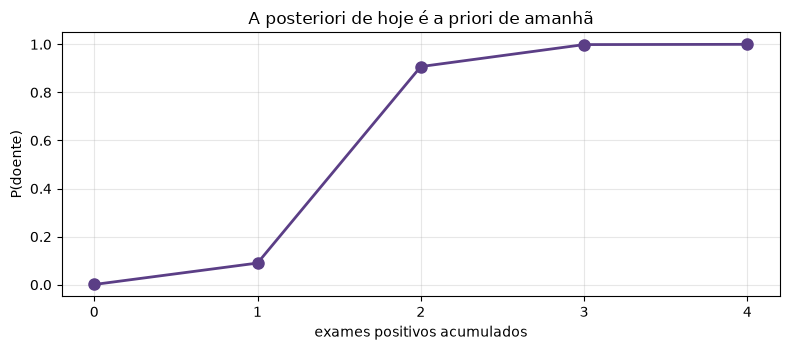

In [5]:
crenca = PREVALENCIA
historico = [crenca]
for k in range(1, 5):
    crenca = bayes(crenca, SENSIBILIDADE, 1 - ESPECIFICIDADE)
    historico.append(crenca)
    print(f"após {k} exame(s) positivo(s): P(doente) = {crenca:.4f}  ({crenca:.1%})")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(range(len(historico)), historico, "o-", color=ROXO, lw=2, ms=8)
ax.set_xticks(range(len(historico)))
ax.set_xlabel("exames positivos acumulados"); ax.set_ylabel("P(doente)")
ax.set_title("A posteriori de hoje é a priori de amanhã")
plt.tight_layout(); plt.show()

Dois positivos independentes levam a crença de 9% para 91%. **Essa é a razão
de existir do exame confirmatório** — e note que a ordem não importa: aplicar
Bayes em qualquer sequência dá o mesmo resultado final.

> **A ressalva que médicos conhecem e analistas esquecem:** os dois exames
> precisam ser **condicionalmente independentes** dado o estado real. Repetir o
> *mesmo* exame na *mesma* amostra não é evidência nova — se o erro for
> sistemático, ele se repete idêntico.

## 4. De hipótese binária para parâmetro contínuo

Até aqui, $\theta$ tinha dois valores (doente / saudável). O caso geral é
$\theta$ contínuo — por exemplo, a taxa de conversão de uma landing page.

Vamos fazer a inferência **na força bruta**: discretizar o espaço de $\theta$
em uma grade fina, calcular priori × verossimilhança em cada ponto e
normalizar. É literalmente o teorema de Bayes, sem nenhuma matemática
adicional — e é a melhor forma de ver a posteriori se formar.

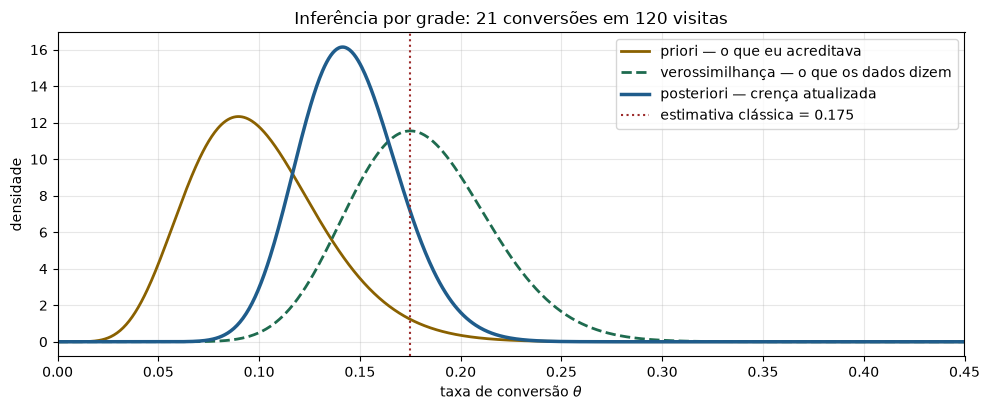

In [6]:
grade = np.linspace(0, 1, 2001)

# priori: acreditamos que a conversão fica em torno de 10%, com folga
priori = stats.beta.pdf(grade, 8, 72)
priori /= np.trapezoid(priori, grade)

VISITAS, CONVERSOES = 120, 21
verossimilhanca = stats.binom.pmf(CONVERSOES, VISITAS, grade)

nao_normalizada = verossimilhanca * priori
posteriori = nao_normalizada / np.trapezoid(nao_normalizada, grade)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(grade, priori, color=AMBAR, lw=2, label="priori — o que eu acreditava")
ax.plot(grade, verossimilhanca / np.trapezoid(verossimilhanca, grade), color=VERDE,
        lw=2, ls="--", label="verossimilhança — o que os dados dizem")
ax.plot(grade, posteriori, color=AZUL, lw=2.5, label="posteriori — crença atualizada")
ax.axvline(CONVERSOES / VISITAS, color=VERMELHO, lw=1.5, ls=":",
           label=f"estimativa clássica = {CONVERSOES/VISITAS:.3f}")
ax.set_xlim(0, 0.45)
ax.set_xlabel(r"taxa de conversão $\theta$"); ax.set_ylabel("densidade")
ax.set_title(f"Inferência por grade: {CONVERSOES} conversões em {VISITAS} visitas")
ax.legend(); plt.tight_layout(); plt.show()

A posteriori (azul) fica **entre** a priori e a verossimilhança — mais perto da
verossimilhança, porque 120 visitas já são informativas o bastante para puxar a
crença. Com 12 visitas, ela ficaria colada na priori; com 12.000, colada nos dados.

## 5. Resumindo a posteriori: média, MAP e intervalo de credibilidade

média posterior     0.1450
MAP (moda)          0.1415
estimativa clássica 0.1750

Intervalo de credibilidade 95%: [0.1000, 0.1970]
Leitura: há 95% de probabilidade de a conversão real estar nesse intervalo.
(Essa frase é ILEGÍTIMA para um intervalo de confiança — e é a diferença
 que mais importa na hora de comunicar o resultado.)


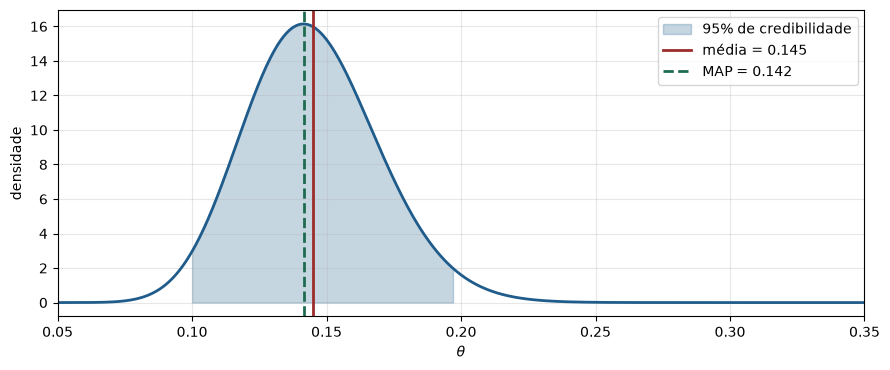

In [7]:
media_post = np.trapezoid(grade * posteriori, grade)
mapa = grade[posteriori.argmax()]

acumulada = np.cumsum(posteriori) * (grade[1] - grade[0])
ic_inf = grade[np.searchsorted(acumulada, 0.025)]
ic_sup = grade[np.searchsorted(acumulada, 0.975)]

print(f"média posterior     {media_post:.4f}")
print(f"MAP (moda)          {mapa:.4f}")
print(f"estimativa clássica {CONVERSOES/VISITAS:.4f}")
print(f"\nIntervalo de credibilidade 95%: [{ic_inf:.4f}, {ic_sup:.4f}]")
print("Leitura: há 95% de probabilidade de a conversão real estar nesse intervalo.")
print("(Essa frase é ILEGÍTIMA para um intervalo de confiança — e é a diferença")
print(" que mais importa na hora de comunicar o resultado.)")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(grade, posteriori, color=AZUL, lw=2)
faixa = (grade >= ic_inf) & (grade <= ic_sup)
ax.fill_between(grade[faixa], posteriori[faixa], color=AZUL, alpha=0.25,
                label="95% de credibilidade")
ax.axvline(media_post, color=VERMELHO, lw=2, label=f"média = {media_post:.3f}")
ax.axvline(mapa, color=VERDE, lw=2, ls="--", label=f"MAP = {mapa:.3f}")
ax.set_xlim(0.05, 0.35); ax.set_xlabel(r"$\theta$"); ax.set_ylabel("densidade")
ax.legend(); plt.tight_layout(); plt.show()

## 6. A pergunta que só o bayesiano responde

Com a posteriori em mãos, perguntas de negócio viram integrais — e integrais
viram médias sobre amostras.

In [8]:
amostras_post = rng.choice(grade, size=200_000, p=posteriori / posteriori.sum())

print(f"P(conversão > 15%)          = {(amostras_post > 0.15).mean():.4f}")
print(f"P(conversão entre 12% e 20%)= {((amostras_post > 0.12) & (amostras_post < 0.20)).mean():.4f}")
print(f"P(conversão < 10%)          = {(amostras_post < 0.10).mean():.4f}")

# valor esperado de uma decisão: campanha custa R$ 4 por visita, cada conversão vale R$ 40
CUSTO_VISITA, VALOR_CONVERSAO = 4.0, 40.0
lucro_por_visita = amostras_post * VALOR_CONVERSAO - CUSTO_VISITA
print(f"\nlucro esperado por visita     = R$ {lucro_por_visita.mean():+.3f}")
print(f"P(a campanha dar prejuízo)    = {(lucro_por_visita < 0).mean():.4f}")

P(conversão > 15%)          = 0.3979
P(conversão entre 12% e 20%)= 0.8208
P(conversão < 10%)          = 0.0249

lucro esperado por visita     = R$ +1.796
P(a campanha dar prejuízo)    = 0.0249


**Esse é o ponto de virada prático.** "P(prejuízo) = 12%" é uma frase que um
diretor consegue usar para decidir. "p = 0,03" não é.

A posteriori não é o fim da análise — é o insumo de uma **decisão sob
incerteza**, e toda função de custo do negócio pode ser integrada contra ela.

## O que levar deste notebook

- Bayes é **contagem**: fórmula é só o atalho para contar pessoas nas caselas.
- A **taxa-base domina** eventos raros — o erro mais caro em classificação.
- Priori não é opcional; não declarar uma é assumir a uniforme sem admitir.
- **Posteriori de hoje = priori de amanhã.** Atualização sequencial é livre.
- Inferência por grade resolve qualquer problema de 1 ou 2 parâmetros sem
  nenhuma matemática além de multiplicar e normalizar.
- Da posteriori saem **probabilidades de eventos** e **valores esperados de
  decisões** — o que ninguém consegue extrair de um p-valor.

→ No próximo notebook: as **famílias conjugadas**, que substituem a grade por
aritmética exata.